In [50]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [5]:
data = pd.read_csv("spotify_churn_dataset.csv")
data.head(2)

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0


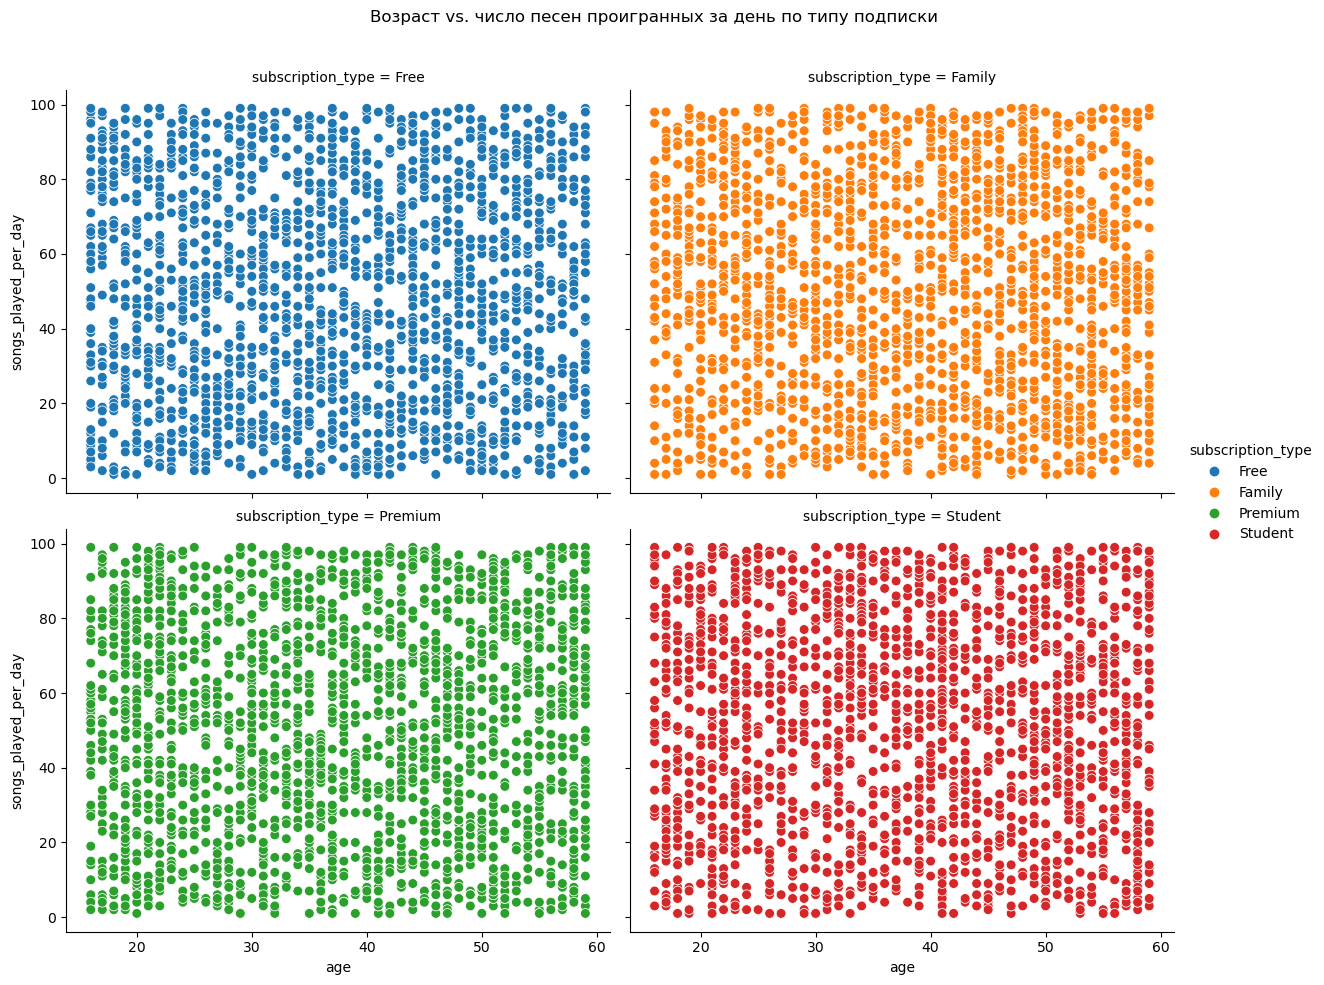

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.relplot(
    data=data,
    x='age', 
    y='songs_played_per_day',
    kind='scatter', 
    col='subscription_type',  # параметр для создания отдельного графика по каждой категории
    hue='subscription_type',  
    s=50,
    col_wrap=2,  
    height=5, 
    aspect=1.2
)

plt.subplots_adjust(top=0.9) 
plt.suptitle("Возраст vs. число песен проигранных за день по типу подписки")
plt.show()

In [21]:
data.head(2)

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0


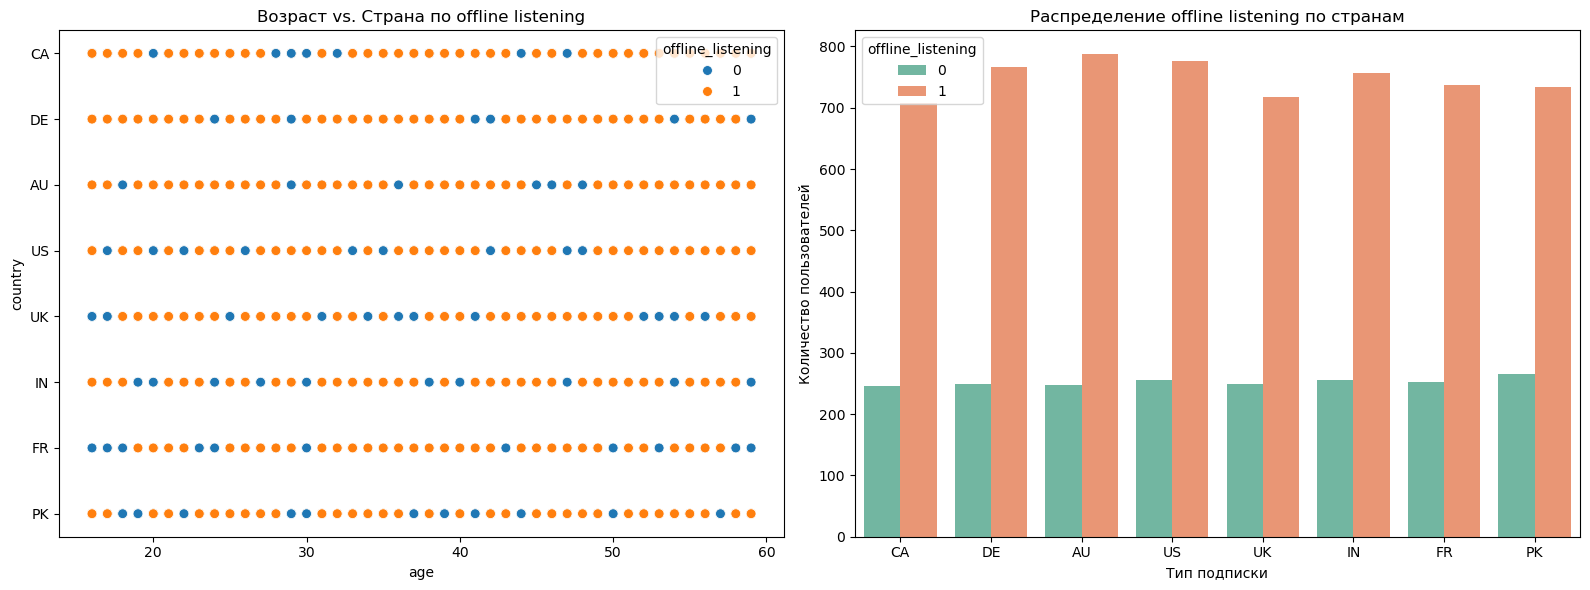

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    data=data,
    x='age',
    y='country',
    hue='offline_listening',
    s=50,
    ax=axes[0]
)
axes[0].set_title("Возраст vs. Страна по offline listening")

sns.countplot(
    data=data,
    x='country',
    hue='offline_listening',
    palette='Set2',
    ax=axes[1]
)
axes[1].set_title("Распределение offline listening по странам")
axes[1].set_xlabel("Тип подписки")
axes[1].set_ylabel("Количество пользователей")

plt.tight_layout()
plt.show()


In [35]:
data.head(2)

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0


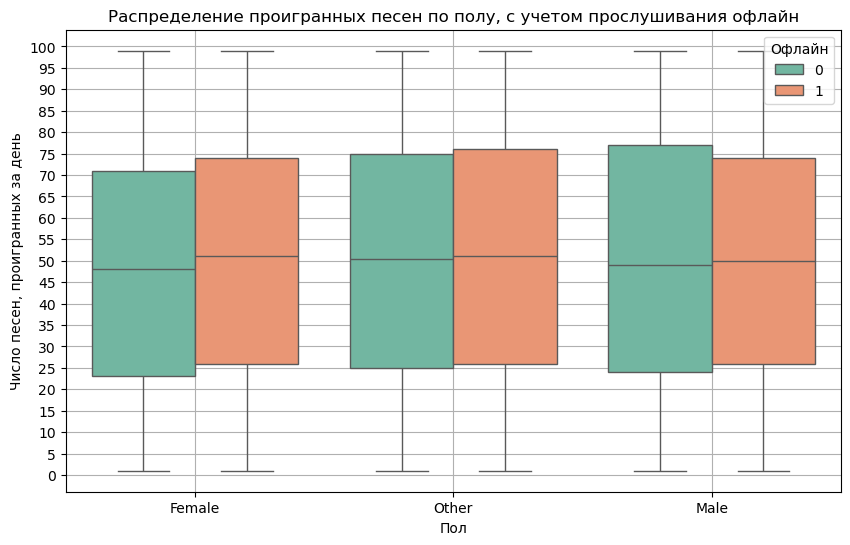

In [44]:
from matplotlib.ticker import MultipleLocator
plt.figure(figsize=(10, 6))

ax =sns.boxplot(
    data=data, 
    x='gender',  
    y='songs_played_per_day', 
    hue='offline_listening', 
    palette='Set2'
)
ax.yaxis.set_major_locator(MultipleLocator(5))

plt.title("Распределение проигранных песен по полу, с учетом прослушивания офлайн")
plt.xlabel("Пол")
plt.ylabel("Число песен, проигранных за день")
plt.grid(visible=True, which='major')
plt.legend(title="Офлайн") 
plt.show()

In [45]:
data.head(2)

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0


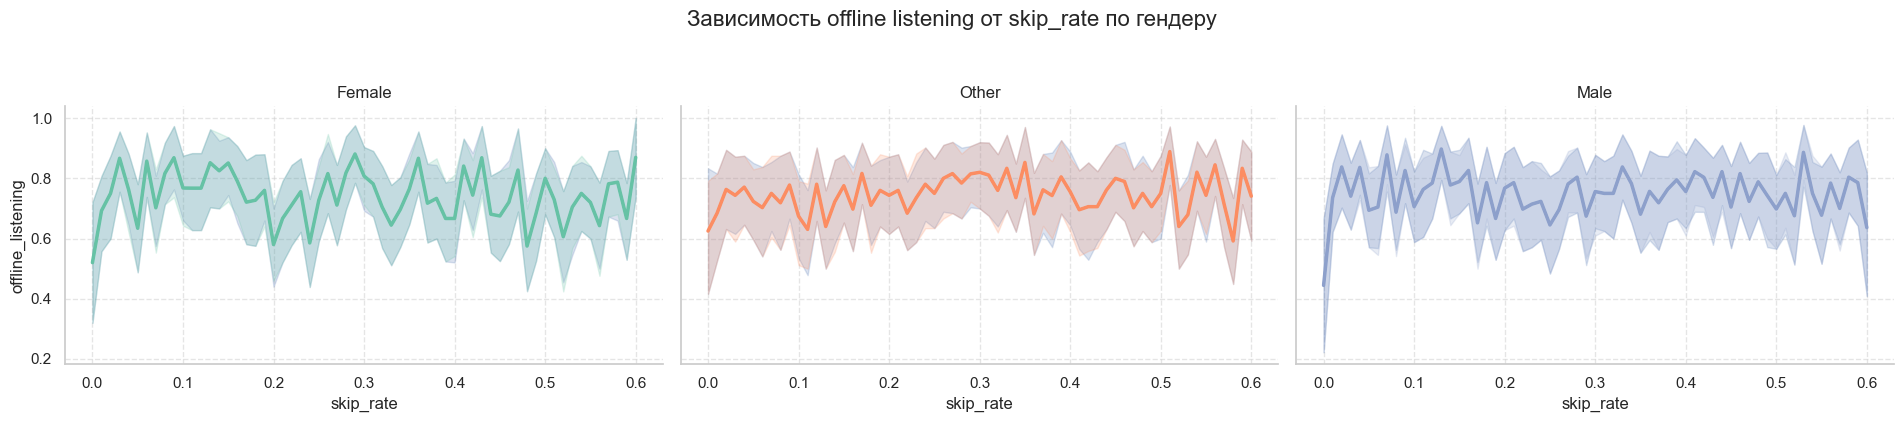

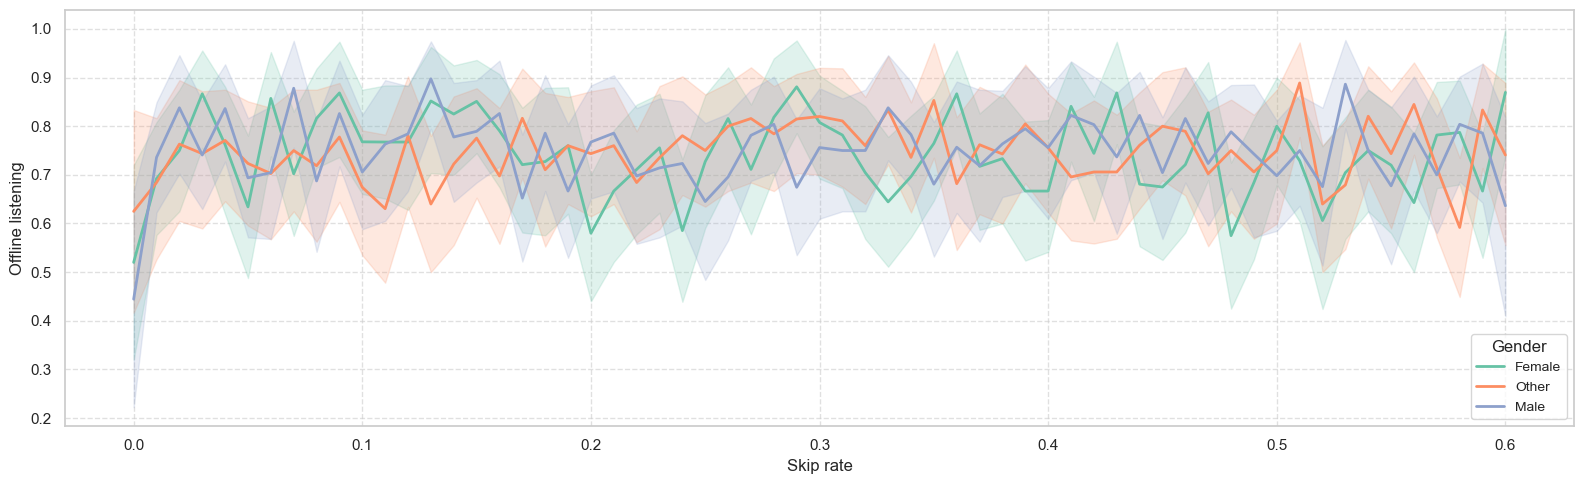

In [65]:
sns.set_theme(style="whitegrid")

palette = sns.color_palette("Set2")
gender_colors = dict(zip(data["gender"].unique(), palette))

g = sns.FacetGrid(data, col="gender", col_wrap=3, height=4, aspect=1.6, sharex=True, sharey=True)

g.map_dataframe(
    sns.lineplot,
    x="skip_rate",
    y="offline_listening",
    color=None,  
)

for ax, gender in zip(g.axes.flatten(), data["gender"].unique()):
    gender_data = data[data["gender"] == gender]
    sns.lineplot(
        data=gender_data,
        x="skip_rate",
        y="offline_listening",
        color=gender_colors[gender],
        linewidth=2.5,
        ax=ax
    )
    ax.set_title(gender, fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)


g.fig.suptitle("Зависимость offline listening от skip_rate по гендеру", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 5))
sns.lineplot(
    data=data,
    x="skip_rate",
    y="offline_listening",
    hue="gender",       
    palette="Set2",
    linewidth=2
)
plt.xlabel("Skip rate", fontsize=12)
plt.ylabel("Offline listening", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Gender", fontsize=10)
plt.tight_layout()
plt.show()

